In [1]:
#!rm -rf /content/drive
#load data from google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.listdir('/content/drive/MyDrive/hackathon_team02')

Mounted at /content/drive


['Copy of understand_amazon_transcribe.gdoc',
 'Copy of commit_record.gdoc',
 'output20260400',
 'transcripts_contents_only_tagged']

In [2]:
import json
import os

# --- 設定區 -------------------------------------------------------------------
# 設定來源 JSON 資料夾與輸出文字資料夾
# 設定要處理的檔案數量，若設為 None 則處理全部 1800 筆
path = '/content/drive/MyDrive/hackathon_team02'
MAX_FILES = 3
subfolder_name = 'output20260401'
input_folder = path + subfolder_name
output_folder = path + '/transcripts_contents_only_tagged/' + subfolder_name
# ------------------------------------------------------------------------------

# 如果輸出資料夾不存在，則建立它
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

def process_json(file_path, output_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    transcript_list = data.get('Transcript', [])
    formatted_lines = []

    for entry in transcript_list:
        role = entry.get('ParticipantId', 'UNKNOWN')
        content = entry.get('Content', '')
        # 加上角色標籤
        formatted_lines.append(f"[{role}]: {content}")

    with open(output_path, 'w', encoding='utf-8') as f_out:
        f_out.write("\n".join(formatted_lines))

# 取得所有 json 檔案清單
all_json_files = [f for f in os.listdir(input_folder) if f.endswith('.json')]

# 根據 MAX_FILES 參數截取檔案清單
files_to_process = all_json_files[:MAX_FILES] if MAX_FILES is not None else all_json_files

print(f"準備處理 {len(files_to_process)} 個檔案 (總數: {len(all_json_files)})...")

for i, filename in enumerate(files_to_process):
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename.replace('.json', '.txt'))

    try:
        process_json(input_path, output_path)
        print(f"[{i+1}/{len(files_to_process)}] 成功轉換: {filename}")
    except Exception as e:
        print(f"[{i+1}/{len(files_to_process)}] 轉換失敗 {filename}: {e}")

print(f"\n--- 處理完畢！檔案已儲存至 {output_folder} ---")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/hackathon_team02output20260401'

In [ ]:
print(files_to_process)

['87de2374-2d06-4a35-908c-7e4c615131e4_analysis_redacted_2026-04-01T00_11_31Z.json', 'c523342c-607a-4060-91bf-4c881ab4079d_analysis_redacted_2026-04-01T00_09_22Z.json', 'b0dacf11-7cff-42fe-b5f0-e68971721921_analysis_redacted_2026-04-01T00_06_18Z.json']


In [ ]:
import json
import os

# ==========================================
# 🔧 使用者設定區
# ==========================================

# 1. 基礎路徑設定
BASE_PATH = input_folder
output_folder = path + '/transcripts_formatting_full/' + subfolder_name
OUTPUT_PATH = output_folder

# 2. 模式選擇 (True: 處理資料夾所有檔案 / False: 處理下方清單)
PROCESS_ALL_IN_FOLDER = False

# 3. 手動指定的檔案名稱清單
json_file_list = files_to_process

# ==========================================
# ⚙️ 核心邏輯區
# ==========================================

def generate_report(f_name):
    full_input_path = os.path.join(BASE_PATH, f_name)
    if not os.path.exists(full_input_path):
        return

    try:
        with open(full_input_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        chars = data.get('ConversationCharacteristics', {})
        sentiment = chars.get('Sentiment', {}).get('OverallSentiment', {})
        talk_speed = chars.get('TalkSpeed', {}).get('DetailsByParticipant', {})
        interruptions = chars.get('Interruptions', {})

        report = []
        report.append(f"{'='*60}\n")
        report.append(f" 📊 通話分析報告: {f_name}\n")
        report.append(f"{'='*60}\n\n")

        # --- 1. Amazon 分析數據區 ---
        report.append("【1. 關鍵分析數據 (Analytics)】\n")
        report.append(f" ● 整體情緒分數 (Sentiment):\n")
        report.append(f"   - 顧問 (AGENT): {sentiment.get('AGENT', 'N/A')}\n")
        report.append(f"   - 客戶 (CUSTOMER): {sentiment.get('CUSTOMER', 'N/A')}\n")

        report.append(f" ● 平均語速 (Words Per Minute):\n")
        report.append(f"   - 顧問: {talk_speed.get('AGENT', {}).get('AverageWordsPerMinute', 'N/A')} WPM\n")
        report.append(f"   - 客戶: {talk_speed.get('CUSTOMER', {}).get('AverageWordsPerMinute', 'N/A')} WPM\n")

        report.append(f" ● 插嘴次數 (Interruptions): {interruptions.get('TotalCount', 0)} 次\n")
        report.append(f" ● 通話總時長: {chars.get('TotalConversationDurationMillis', 0) / 1000} 秒\n\n")

        # --- 2. 逐字稿內容區 ---
        report.append("-" * 60 + "\n")
        report.append("【2. 對話內容 (Transcript)】\n")
        report.append("-" * 60 + "\n\n")

        for entry in data.get('Transcript', []):
            role = entry.get('ParticipantId', 'UNKNOWN')
            content = entry.get('Content', '')
            if role == 'AGENT':
                report.append(f"[AGENT]: {content}\n\n")
            else:
                report.append(f"  > [CUSTOMER]: {content}\n\n")

        # --- 儲存檔案 ---
        if not os.path.exists(OUTPUT_PATH):
            os.makedirs(OUTPUT_PATH)

        out_f_name = f_name.replace('.json', '_analysis_report.txt')
        with open(os.path.join(OUTPUT_PATH, out_f_name), 'w', encoding='utf-8') as f_out:
            f_out.writelines(report)

    except Exception as e:
        # 僅在發生錯誤時打印，確保你知道哪些檔案失敗
        print(f"❌ 處理檔案 {f_name} 失敗: {str(e)}")

if __name__ == "__main__":
    files = [f for f in os.listdir(BASE_PATH) if f.endswith('.json')] if PROCESS_ALL_IN_FOLDER else json_file_list
    print(f"🚀 開始批次產出報告至: {OUTPUT_PATH}")
    for f_name in files:
        generate_report(f_name)
    print("🎉 任務完成！")

🚀 開始批次產出報告至: /content/drive/MyDrive/hackathon_team02/transcripts_formatting_full/output20260401
🎉 任務完成！


In [ ]:
print(input_folder)

In [3]:
# 統計Conversation Characteristics, 有些檔案只有一個人講話, 把那些檔案加入exclude list

import json
import os
import numpy as np

# ==========================================
# 🔧 使用者設定區
# ==========================================

# 1. 基礎路徑設定
BASE_PATH = '/content/drive/MyDrive/hackathon_team02/output20260400'
#output_folder = path + '/transcripts_formatting_full/' + subfolder_name
#OUTPUT_PATH = output_folder
OUTPUT_EXCLUDE_FILE = BASE_PATH + '/exclude_list.txt'

# 3. 手動指定的檔案名稱清單 (僅在模式為 False 時生效)
json_file_list = False#\
#[
#    '797c87c5-6aec-4d81-aaa0-d176d0fafe2b_analysis_redacted_2026-04-02T02_10_16Z.json',
#    '0b5c88ec-b28c-4bdf-b0d3-335b74b2ed6b_analysis_redacted_2026-04-01T02_00_17Z.json',
#    'test.json'
#]

# ==========================================
# ⚙️ 核心統計邏輯區
# ==========================================

def get_summary_stats(data_list):
    """計算數值清單的基礎統計量"""
    if not data_list:
        return "N/A"
    return {
        "Min": round(float(np.min(data_list)), 2),
        "Median": round(float(np.median(data_list)), 2),
        "Max": round(float(np.max(data_list)), 2)
    }

def run_comprehensive_eda():
    # 初始化統計容器
    storage = {
        "Interruptions_TotalCount": [],
        "NonTalkTime_TotalTimeMillis": [],
        "Sentiment_Agent": [],
        "Sentiment_Customer": [],
        "TalkSpeed_Agent": [],
        "TalkSpeed_Customer": [],
        "TalkTime_Agent": [],
        "TalkTime_Customer": [],
        # 音量特徵
        "Loudness_Agent_Std": [],    # 顧問音量標準差 (波動程度)
        "Loudness_Customer_Std": [], # 客戶音量標準差 (波動程度)
        "Loudness_Agent_Mean": [],  # 顧問音量平均
        "Loudness_Customer_Mean": []# 客戶音量平均
    }

    # ❌ 記錄異常檔案清單
    exclude_list = []
    processed_count = 0

    for root, dirs, files in os.walk(BASE_PATH):
        # 過濾出 JSON 檔案
        if json_file_list == False:
            json_files = [f for f in files if f.endswith('.json')]
        else:
            json_files = json_file_list

        print(f"🚀 開始分析 {len(json_files)} 個檔案...")

        for f_name in json_files:
            full_path = os.path.join(root, f_name)
            processed_count = processed_count + 1
            if not os.path.exists(full_path):
                continue
            #print(full_path)
            try:
                with open(full_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                if 'ConversationCharacteristics' not in data:
                    print(f"🔍 檔案 {f_name} 格式不完整 (缺少特徵區塊)")
                    exclude_list.append(f_name); continue
                else:
                    char = data['ConversationCharacteristics']

                # 1. Interruptions & 2. NonTalkTime
                interruptions_data = char.get('Interruptions')
                if interruptions_data is not None and 'TotalCount' in interruptions_data:
                    # 只有在格式完全正確時才加入統計
                    val = interruptions_data['TotalCount']
                    storage["Interruptions_TotalCount"].append(val)
                else:
                    # 如果找不到欄位，印出警告，方便你回頭檢查那個 JSON 檔
                    print(f"🔍 檔案 {f_name}: 缺少 Interruptions.TotalCount 資訊")
                    exclude_list.append(f_name); continue

                nontalktime_data = char.get('NonTalkTime')
                if nontalktime_data is not None and 'TotalTimeMillis' in nontalktime_data:
                    # 只有在格式完全正確時才加入統計
                    val = nontalktime_data['TotalTimeMillis']
                    if val == 415647.0:
                        print(f"🔍 檔案 {root}{f_name}: ['NonTalkTime']['TotalTimeMillis'] = 415647.0")
                    storage["NonTalkTime_TotalTimeMillis"].append(val)
                else:
                    # 如果找不到欄位，印出警告，方便你回頭檢查那個 JSON 檔
                    print(f"🔍 檔案 {f_name}: 缺少 NonTalkTime.TotalTimeMillis 資訊")
                    exclude_list.append(f_name); continue

                # 3. Sentiment

                # 1. 先抓取 TalkTime 第一層
                semtiment_data = char.get('Sentiment')
                if semtiment_data is not None and 'OverallSentiment' in semtiment_data:
                    # 2. 進入第二層 DetailsByParticipant
                    details = semtiment_data['OverallSentiment']

                    # 3. 檢查 AGENT 數據
                    if 'AGENT' in details:
                        storage["Sentiment_Agent"].append(details['AGENT'])
                    else:
                        print(f"🔍 檔案 {f_name}: 缺少 Sentiment.OverallSentiment.AGENT 資訊")
                        exclude_list.append(f_name); continue
                        # 如果你希望即便缺失也補個 0，可以在這裡 append(0)

                    # 4. 檢查 CUSTOMER 數據
                    if 'CUSTOMER' in details:
                        storage["Sentiment_Customer"].append(details['CUSTOMER'])
                    else:
                        print(f"🔍 檔案 {f_name}: 缺少 Sentiment.OverallSentiment.CUSTOMER 資訊")
                        exclude_list.append(f_name); continue
                else:
                    # 如果第一或第二層就掛了
                    print(f"🔍 檔案 {f_name}: 缺少 Sentiment 或 OverallSentiment 結構")
                    exclude_list.append(f_name); continue

                # 4. TalkSpeed

                # 1. 先抓取 TalkTime 第一層
                talkspeed_data = char.get('TalkSpeed')
                if talkspeed_data is not None and 'DetailsByParticipant' in talkspeed_data:
                    # 2. 進入第二層 DetailsByParticipant
                    details = talkspeed_data['DetailsByParticipant']

                    # 3. 檢查 AGENT 數據
                    if 'AGENT' in details and 'AverageWordsPerMinute' in details['AGENT']:
                        if details['AGENT']['AverageWordsPerMinute'] == 0:
                            print(f"🔍 檔案 {f_name}: ['AGENT']['AverageWordsPerMinute'] = 0")
                            exclude_list.append(f_name); continue
                        else:
                            storage["TalkSpeed_Agent"].append(details['AGENT']['AverageWordsPerMinute'])
                    else:
                        print(f"🔍 檔案 {f_name}: 缺少 TalkSpeed.DetailsByParticipant.AGENT 資訊")
                        exclude_list.append(f_name); continue
                        # 如果你希望即便缺失也補個 0，可以在這裡 append(0)

                    # 4. 檢查 CUSTOMER 數據
                    if 'CUSTOMER' in details and 'AverageWordsPerMinute' in details['CUSTOMER']:
                        if details['CUSTOMER']['AverageWordsPerMinute'] == 0:
                            print(f"🔍 檔案 {f_name}: ['CUSTOMER']['AverageWordsPerMinute'] = 0")
                            exclude_list.append(f_name); continue
                        else:
                            storage["TalkSpeed_Customer"].append(details['CUSTOMER']['AverageWordsPerMinute'])
                    else:
                        print(f"🔍 檔案 {f_name}: 缺少 TalkSpeed.DetailsByParticipant.CUSTOMER 資訊")
                        exclude_list.append(f_name); continue
                else:
                    # 如果第一或第二層就掛了
                    print(f"🔍 檔案 {f_name}: 缺少 TalkSpeed 或 DetailsByParticipant 結構")
                    exclude_list.append(f_name); continue

                # 5. TalkTime

                # 1. 先抓取 TalkTime 第一層
                talktime_data = char.get('TalkTime')
                if talktime_data is not None and 'DetailsByParticipant' in talktime_data:
                    # 2. 進入第二層 DetailsByParticipant
                    details = talktime_data['DetailsByParticipant']

                    # 3. 檢查 AGENT 數據
                    if 'AGENT' in details and 'TotalTimeMillis' in details['AGENT']:
                        storage["TalkTime_Agent"].append(details['AGENT']['TotalTimeMillis'])
                    else:
                        print(f"🔍 檔案 {f_name}: 缺少 TalkTime.DetailsByParticipant.AGENT 資訊")
                        exclude_list.append(f_name); continue
                        # 如果你希望即便缺失也補個 0，可以在這裡 append(0)

                    # 4. 檢查 CUSTOMER 數據
                    if 'CUSTOMER' in details and 'TotalTimeMillis' in details['CUSTOMER']:
                        storage["TalkTime_Customer"].append(details['CUSTOMER']['TotalTimeMillis'])
                    else:
                        print(f"🔍 檔案 {f_name}: 缺少 TalkTime.DetailsByParticipant.CUSTOMER 資訊")
                        exclude_list.append(f_name); continue
                else:
                    # 如果第一或第二層就掛了
                    print(f"🔍 檔案 {f_name}: 缺少 TalkTime 或 DetailsByParticipant 結構")
                    exclude_list.append(f_name); continue

                # 6. Loudness 分析 (針對檔案內所有說話片段計算波動)

                transcript_data = data.get('Transcript')
                if isinstance(transcript_data, list):
                    agent_all_scores = []
                    cust_all_scores = []

                    for entry in transcript_data:
                        # 2. 檢查 entry 裡面是否有必要的 Key
                        p_id = entry.get('ParticipantId')
                        scores = entry.get('LoudnessScore')

                        #if f_name == '87de2374-2d06-4a35-908c-7e4c615131e4_analysis_redacted_2026-04-01T00_11_31Z.json':
                        #if f_name == 'c93e2f40-ccac-45cb-bfe7-7d6c769050a8_analysis_redacted_2026-04-01T23_08_17Z.json':
                            #print(p_id)
                            #print(scores)

                        # 確保 p_id 存在且 scores 是列表 (避免 null 或格式錯誤)
                        if p_id is not None and isinstance(scores, list):
                            #if f_name == '87de2374-2d06-4a35-908c-7e4c615131e4_analysis_redacted_2026-04-01T00_11_31Z.json':
                            #if f_name == 'c93e2f40-ccac-45cb-bfe7-7d6c769050a8_analysis_redacted_2026-04-01T23_08_17Z.json':
                                #print("A:",agent_all_scores)
                                #print("C:",cust_all_scores)
                            if p_id == 'AGENT':
                                agent_all_scores.extend(scores)
                            elif p_id == 'CUSTOMER':
                                cust_all_scores.extend(scores)
                            #if f_name == '87de2374-2d06-4a35-908c-7e4c615131e4_analysis_redacted_2026-04-01T00_11_31Z.json':
                            #if f_name == 'c93e2f40-ccac-45cb-bfe7-7d6c769050a8_analysis_redacted_2026-04-01T23_08_17Z.json':
                                #print("A:",agent_all_scores)
                                #print("C:",cust_all_scores)
                        else:
                            print(f"🔍 檔案 {f_name}: 某條 Transcript 缺失 ParticipantId 或 LoudnessScore")
                            exclude_list.append(f_name); continue

                    if not cust_all_scores or not agent_all_scores:
                        # 如果這行對話少了關鍵資訊，可以印出警告 (可選)
                        print(f"🔍 檔案 {f_name}: 只有customer或agent講話")
                        exclude_list.append(f_name); continue

                    # 3. 迴圈結束後，進行音量統計 (使用之前建議的過濾門檻 50)
                    def process_loudness(scores_list, participant_name):
                        # 排除靜音干擾
                        filtered = [s for s in scores_list if s is not None and s > 50]
                        if filtered:
                            storage[f"Loudness_{participant_name}_Mean"].append(np.mean(filtered))
                            storage[f"Loudness_{participant_name}_Std"].append(np.std(filtered))
                        else:
                            print(f"🔍 檔案 {f_name}: {participant_name} 沒有有效的音量數據 (皆低於門檻)")

                    process_loudness(agent_all_scores, "Agent")
                    process_loudness(cust_all_scores, "Customer")

                else:
                    print(f"🔍 檔案 {f_name}: 缺少 Transcript 區塊或格式錯誤")
                    exclude_list.append(f_name); continue

            except json.JSONDecodeError:
                # 專門抓空檔案或格式錯誤
                print(f"🚨 檔案 {f_name}: 無法解析 JSON (可能是空檔或格式損壞)")
                exclude_list.append(f_name)
            except Exception as e:
                # 抓其他預期外的錯誤 (例如權限問題)
                print(f"🚨 檔案 {f_name}: 發生預期外錯誤 {e}")
                exclude_list.append(f_name)

    # ==========================================
    # 💾 寫出排除名單到檔案
    # ==========================================
    if exclude_list:
        try:
            with open(OUTPUT_EXCLUDE_FILE, 'w', encoding='utf-8') as f_out:
                for item in exclude_list:
                    f_out.write(f"{item}\n")
            print(f"\n💾 排除名單已儲存至: {OUTPUT_EXCLUDE_FILE}")
        except Exception as e:
            print(f"❌ 無法寫出排除檔案: {e}")

    # --- 輸出報告 ---
    print("\n" + "="*60)
    print("📊 綜合檔案數[", processed_count, "]特徵分布與音量波動分析報告")
    print("="*60)

    for feature, values in storage.items():
        stats = get_summary_stats(values)
        print(f"\n🔹 {feature}")
        if isinstance(stats, dict):
            print(f"   [最小值]: {stats['Min']} | [中位數]: {stats['Median']} | [最大值]: {stats['Max']}")
        else:
            print(f"   {stats}")

if __name__ == "__main__":
    run_comprehensive_eda()

🚀 開始分析 0 個檔案...
🚀 開始分析 142 個檔案...
🔍 檔案 954f2576-776e-415b-b5ac-5e2b4b616a40_analysis_redacted_2026-04-01T21_36_56Z.json: ['CUSTOMER']['AverageWordsPerMinute'] = 0
🔍 檔案 3de22d00-4359-43be-8bea-db20392805dc_analysis_redacted_2026-04-01T23_20_34Z.json: ['AGENT']['AverageWordsPerMinute'] = 0
🚀 開始分析 55 個檔案...
🔍 檔案 95c537dd-2f60-435e-b58c-86ac0c51a628_analysis_redacted_2026-04-02T01_15_18Z.json: ['CUSTOMER']['AverageWordsPerMinute'] = 0
🚀 開始分析 148 個檔案...
🔍 檔案 ade70b6b-7969-4a0f-b301-14be83e6798b_analysis_redacted_2026-04-07T20_42_12Z.json: ['AGENT']['AverageWordsPerMinute'] = 0
🔍 檔案 9ce87f46-af9c-460b-a793-8354642f42c6_analysis_redacted_2026-04-07T20_49_51Z.json: ['AGENT']['AverageWordsPerMinute'] = 0
🚀 開始分析 160 個檔案...
🔍 檔案 57f6c659-bbc5-430e-bcfc-8c907fb0cfff_analysis_redacted_2026-04-09T00_37_06Z.json: ['AGENT']['AverageWordsPerMinute'] = 0
🔍 檔案 110eb65e-93cb-4385-ae1b-169808f6941a_analysis_redacted_2026-04-09T00_35_54Z.json: ['AGENT']['AverageWordsPerMinute'] = 0
🔍 檔案 21a72d22-ea4f-4d12-9

🚫 已載入黑名單，將跳過 16 個檔案。
⏳ Extracting English Transcripts...
✅ 完成！處理檔案數: 1781, 跳過檔案數: 16

🔥 Top  25  Most Frequent Topics/Words:
months: 4631
doses: 4092
years: 3281
weeks: 2644
funded: 2352
flu: 2256
clinical_risk: 2152
pcv: 1414
infant_core: 1272
booster: 1226
mmr: 1123
age: 1088
hep: 1074
tetanus_pertussis_combo: 1066
authority_policy: 1049
covid: 1032
shingrix: 983
ipv: 963
varicella: 542
evidence_serology: 489
meningococcal: 392
catchup: 328
pregnant: 272
hpv: 252
safety_screening: 206


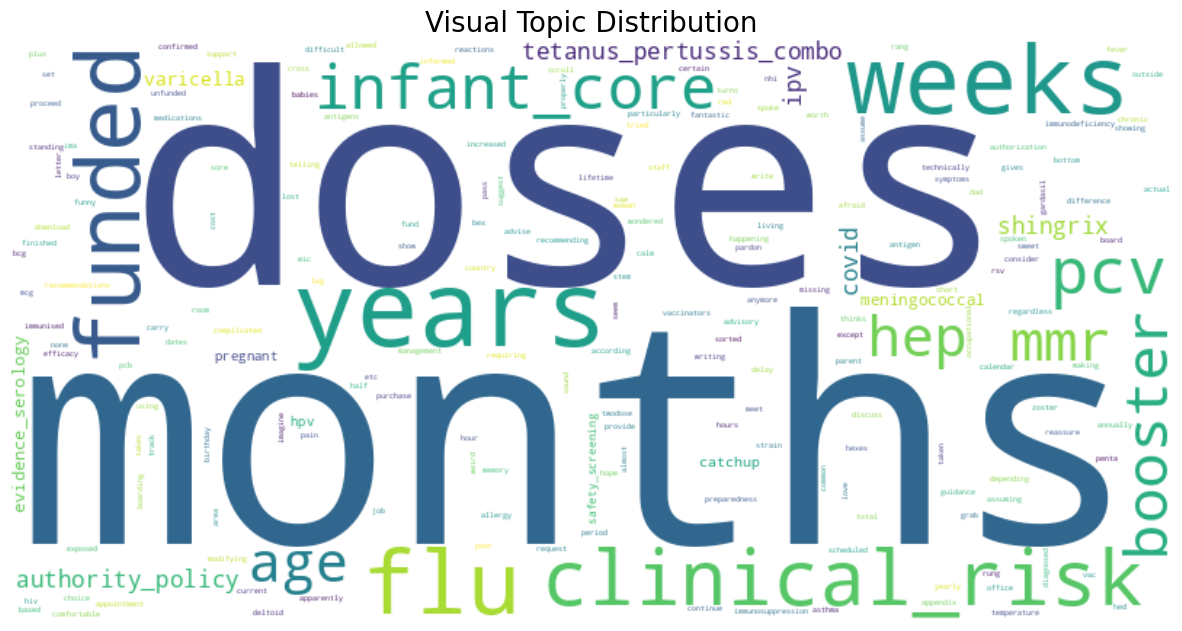

在目前的詞頻統計中找不到 'rotarix'，請確認拼字或 stopwords 設定。


In [ ]:
# English Transcript Word Frequency & WordCloud Script

import os
import json
import re
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# ==========================================
# 🔧 Setup
# ==========================================
PARENT_PATH = '/content/drive/MyDrive/hackathon_team02/output20260400'
EXCLUDE_FILE_PATH = '/content/drive/MyDrive/hackathon_team02/output20260400/exclude_list.txt'
RANK_NUM = 25


def run_english_frequency_analysis():
# 1. 讀取 exclude_list (黑名單)
    exclude_set = set()
    if os.path.exists(EXCLUDE_FILE_PATH):
        with open(EXCLUDE_FILE_PATH, 'r', encoding='utf-8') as f:
            # 讀取每一行並去除空白字元
            exclude_set = {line.strip() for line in f if line.strip()}
        print(f"🚫 已載入黑名單，將跳過 {len(exclude_set)} 個檔案。")
    else:
        print("⚠️ 未找到 exclude_list.txt，將掃描所有檔案。")

    all_text = []
    top_rank_tags = []
    processed_count = 0
    skipped_count = 0

    print("⏳ Extracting English Transcripts...")

    for root, dirs, files in os.walk(PARENT_PATH):
        for f_name in [f for f in files if f.endswith('.json')]:
            full_path = os.path.join(root, f_name)

            # --- 關鍵檢查：如果檔案在黑名單中，就跳過 ---
            # 這裡檢查 full_path 或 f_name，視你當初存入 list 的格式而定
            if full_path in exclude_set or f_name in exclude_set:
                skipped_count += 1
                continue

            try:
                with open(full_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    processed_count = processed_count + 1
                    transcript = data.get('Transcript', [])
                    for entry in transcript:
                        content = entry.get('Content', '')
                        if content:
                            all_text.append(content.lower())
            except:
                skipped_count += 1
                continue

    print(f"✅ 完成！處理檔案數: {processed_count}, 跳過檔案數: {skipped_count}")

    if not all_text:
        print("❌ 沒有可分析的文本數據。")
        return

    # Combine all text
    combined_text = " ".join(all_text)

    # 1. Cleaning: Remove punctuation and non-alphabetic characters
    clean_text = re.sub(r'[^a-zA-Z\s]', '', combined_text)

    # 2. Tokenization & Removing Stopwords
    # We add custom "call center" filler words to STOPWORDS
    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update([
        "thank", "thanks", "hello", "hi", "know", "okay", "um", "uh",
        "right", "yeah", "yes", "like", "well", "now", "go", "will",
        "name", "thats", "one", "got", "good", "bye", "shes", "dont",
        "youre", "mhm", "think", "ive", "give", "ill", "hes", "sorry",
        "can", "get", "just", "going", "see", "theres", "look", "theyre",
        "speaking", "much", "sure", "mean", "email", "address", "say",
        "cool", "want", "back", "given", "need", "probably", "really",
        "help", "let", "fine", "gonna", "yep", "still", "actually",
        "check", "cant", "another", "theyve", "doesnt", "bit", "come",
        "today", "said", "two", "thing", "question", "perfect", "patient",
        "didnt", "isnt", "youve", "whether", "course", "time", "last",
        "second", "first", "lovely", "might", "weve", "welcome", "byebye",
        "nurse", "problem", "old", "sort", "anything", "phone", "child",
        "hold", "day", "done", "wanted", "says", "find", "health",
        "something", "make", "little", "calling", "whats", "morning", "put",
        "people", "quite", "medical", "needs", "great", "thought", "cheers",
        "long", "days", "even", "nurses", "call", "vaccine", "vaccines",
        "vaccination", "vax", "maybe", "worries", "afternoon", "take", "looking",
        "may", "centre", "havent", "cause", "apart", "work", "schedule", "awesome",
        "wouldnt", "correct", "wont", "absolutely", "lets", "send", "different",
        "recommended", "things", "alright", "wait", "number", "better", "early",
        "next", "hasnt", "already", "getting", "definitely", "hey", "moment",
        "information", "please", "tell", "anyway", "catch", "double",
        "kind", "lot", "though", "wasnt", "doctor", "obviously", "later",
        "wondering", "around", "date", "immunisation", "immune", "ones", "primary",
        "ask", "new", "advice", "saying", "practise", "hang", "giving", "ring",
        "way", "care", "ago", "case", "trying", "coming", "pharmacy", "talking",
        "guess", "doctors", "thinking", "wanting", "system", "either",
        "live", "able", "nothing", "called", "yet", "person", "recommend",
        "someone", "talk", "unfortunately", "basically", "list", "vaccinations",
        "response", "quick", "offer", "youll", "everything", "usually", "overseas",
        "went", "try", "itll", "patients", "website", "whos", "zero", "exactly",
        "mom", "due", "pay", "children", "protection", "sheet", "names", "sounds",
        "least", "start", "fact", "use", "disease", "error", "best",
        "always", "wants", "data", "contact", "gave", "air", "minimum", "query",
        "youd", "wonderful", "yup", "older", "happy", "shouldnt", "home", "onto", "whatever", "yearold", "totally", "beautiful", "kids", "per",
        "form", "clinic", "many", "came", "never", "men", "pretty", "couple", "end", "starting", "screening", "speak", "usual", "hell", "lots", "easy", "recently", "straight",
        "hear", "surname", "minute", "history", "big", "unless", "looks", "reason", "feeling", "times", "gentleman", "stage", "message", "olds", "bad", "wound", "reading",
        "guys", "vaccinated", "immunizations", "records", "keep", "record", "immunity", "confusing", "colleague", "heard", "strains", "recorded", "likely", "possibly", "note",
        "sometimes", "enough", "medication", "happened", "clinical", "extra", "wrong", "open", "severe", "childs", "copy", "future", "click", "zealand", "issues", "chapter",
        "within", "sense", "longer", "answer", "needed", "adults", "theyll", "regarding", "girl", "talked", "true", "claim", "consent", "easier", "computer", "training",
        "page", "complete", "documented", "appreciate", "started", "doublecheck", "used", "believe", "seen", "front", "heart", "man", "per", "especially", "add", "blah",
        "criteria", "birth", "every", "family", "born", "checking", "told", "forward", "generally", "suppose", "search", "chat", "gotcha", "access", "higher", "individuals",
        "less", "quickly", "high", "ringing", "certainly", "safe", "lady", "count", "depends", "sheets", "follow", "specific", "notes", "arent", "somebody", "site", "therapy", "fill",
        "comes", "received", "ahead", "asking", "repeat", "means", "travelling", "turned", "found", "waiting", "additional", "remember", "goes", "explain", "run", "incident", "wee",
        "january", "march", "february", "april", "june", "july", "august", "september", "october", "november", "december", # months
        "monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday", #days
        "groups", "understand", "mind", "looked", "taking", "together", "earlier", "top", "issue", "school", "following", "test", "updated", "written", "post", "mum", "fee", "cell",
        "treatment", "online", "leave", "healthy", "local", "table", "three", "separate", "possible", "single", "safety", "available", "following", "whole", "accept", "main", "kia","ora",
        "hopefully", "special", "confirm", "asked", "feel", "till", "order", "interval", "checked", "free", "winter", "life", "considered", "hmm", "stop", "team", "public",
        "turn", "read", "parents", "makes", "arm", "full", "specialist", "group", "vaccinator", "theyd", "fluid", "vaccinating", "often", "previously", "administered", "happen",
        "mens", "past", "away", "working", "young", "third", "place", "side", "must", "made", "wonder", "point", "idea", "gap", "process", "sent", "anyone", "book", "coordinator",
        "matter", "tomorrow", "previous", "couldnt", "excellent", "helpful", "without", "worried", "bear", "education", "close", "terms", "kit", "god", "general", "normal",
        "type", "plan", "situation", "late", "programme", "nice", "covered", "missed", "changed", "important", "questions", "registered", "reaction", "update", "regards",
        "minutes", "clarify", "hard", "recall", "cold", "confused", "soon", "harm", "thatll", "seems", "pop", "injections", "works", "stuff", "details", "uhhuh", "resources",
        "recall", "amazing", "cough", "adult", "gone", "spell", "hospital", "interesting", "url", "left", "spacing", "shell", "far", "rather", "conditions",
        "wanna", "clear", "bring", "wed", "part", "line", "gets", "gosh", "somewhere", "yesterday", "instead", "head", "currently", "valid", "injection", "cover", "vaccinate",
        "needle", "condition", "travel", "administration", "completed", "option", "event", "change", "booked", "visit", "season", "oral", "timing", "infection", "document",
        "prior", "normally", "report", "pharmacist", "shed", "understanding", "standard", "halls", "supposed", "itd", "thatd", "required", "childhood", "administer",
        "seeing", "receive", "aware", "happens", "perhaps", "worry", "brilliant", "righty", "link", "conversation", "agree", "tricky", "require", "effective", "protected",
        "concerns", "potentially", "problems", "advisor", "recommendation", "chain", "concern", "completely", "younger", "sensible", "qualify", "ideally", "unwell", "pre",
        "effects", "across", "busy", "slightly", "changes", "benefit", "discussion", "positive", "university", "fridge", "recent", "google", "eye", "paticularly", "mother",
        "receiving", "low", "fully", "community", "paid", "meant", "word", "anywhere", "box", "national", "honest", "goodness", "hadnt", "bay", "concerned", "whooping",
        "colleagues", "seeing", "receive", "aware", "happens", "respiratory", "advised", "prescribed", 'rest', 'fair',

    ])

    # 1. 定義合併對象 (Key: 保留的字, Value: 要併入的字)
    merge_map = {
        'infant_core': ['hib', 'hexa', 'hip', 'herb', 'infinrix', 'infanrix', 'rotarix', 'rotavirus'],
        'flu': ['flu', 'influenza', 'fluvax', 'influvac', 'quad', 'tetra'],
        'pcv': ['pcv', 'pneumococcal', 'prevnar', 'pneumovax', 'ppv'], # 肺炎鏈球菌主題 (商品名 + 全名 -> 縮寫)
        'shingrix': ['shingrix', 'shinrix', 'shingles', 'zostavax'], #帶狀疱疹
        'ipv': ['ipv', 'polio', 'opv'], # 小兒麻痺
        'hep': ['hep', 'hepatitis'], # 肝炎主題
        'funded': ['funded', 'funding', 'nonfunded', 'eligible', 'eligibility'],
        'varicella': ['varicella', 'chickenpox'], # 水痘主題
        'meningococcal': ['meningococcal', 'bexsero', 'menb', 'meningitis'], # 腦膜炎主題
        'mmr': ['mmr', 'measles', 'mmrs', 'rubella'], #麻疹
        'hpv': ['hpv', 'Gardasil'], #子宮頸癌疫苗
        'covid': ['covid', 'myocarditis'],
        'safety_screening': ['contraindication', 'anaphylaxis'],
        'evidence_serology': ['serology', 'antibodies', 'blood'],
        'tetanus_pertussis_combo': ['tetanus', 'tdap', 'dtap', 'boostrix', 'diphtheria', 'pertussis', 'dtp'], # 破傷風主題
        'clinical_risk': ['immunoglobulin', 'kidney', 'surgery', 'splenectomy', 'antibiotics', 'highrisk', 'chemo', 'transplant', 'immunosuppressant', 'immunocompromised', 'immunosuppressive', 'immunosuppressed', 'chemotherapy', 'cancer', 'methotrexate', 'risk', 'rheumatoid', 'arthritis', ], # 針對特殊族群的複雜諮詢
        'authority_policy': ['script', 'imac', 'pharmac', 'healthcare', 'prescription', 'prescribe', 'prescribed', 'authorities', 'authorised', 'authority', 'guidelines', 'guideline', 'handbook'],
        'catchup': ['catchup', 'ketchup'],
        'booster': ['booster', 'boosters', 'boost'],
        'doses': ['doses', 'dose'],
        'months': ['months', 'month', 'infant', 'baby'],
        'years': ['years', 'year'],
        'weeks': ['weeks', 'week'],
        'pregnant': ['pregnant', 'pregnancy'],
        'age': ['age', 'aged'],
    }

    words = [w for w in clean_text.split() if w not in custom_stopwords and len(w) > 2]

    # 3. Frequency Count
    word_counts = Counter(words)

    new_counts = word_counts.copy()

    for target, sources in merge_map.items():
        total = 0
        for s in sources:
            if s in word_counts:
                total += word_counts[s]
                # 只有當 s 不是目標名稱時才刪除，避免把剛剛算好的刪掉
                if s in new_counts:
                    del new_counts[s]

        # 最後把加總後的數字放回新標籤
        new_counts[target] = total

    word_counts = new_counts

    # Step 3: 將「合併後」的 Counter 餵給 Word Cloud
    # 注意：使用 generate_from_frequencies 而不是 generate(text)
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(word_counts)

    print("\n🔥 Top ", RANK_NUM, " Most Frequent Topics/Words:")
    for word, count in word_counts.most_common(RANK_NUM):
        print(f"{word}: {count}")
        top_rank_tags.append(word)

    plt.figure(figsize=(15, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title("Visual Topic Distribution", fontsize=20)
    plt.show()

    #----------------------------------------------------------------------------
    # 設定目標與基準點
    target_vax = "rotarix"#"myocarditis"#
    threshold = RANK_NUM
    all_sorted = word_counts.most_common()

    # 先找到目標的排名
    target_rank = None
    for rank, (word, freq) in enumerate(all_sorted, 1):
        if word == target_vax.lower():
            target_rank = rank
            target_freq = freq
            break

    if target_rank:
        if target_rank <= threshold:
            print(f"'{target_vax}' 已經在第 {target_rank} 名！")
        else:
            print(f"找到囉！'{target_vax}' 目前排在第 {target_rank} 名，頻率為 {target_freq}")
            print(f"--- 以下是從第 {threshold + 1} 名到目標之間的單字 ---")

            # 打印從第 21 名到目標排名的所有單字 (Python 索引從 0 開始，所以是 threshold:target_rank)
            for i in range(threshold, target_rank):
                r = i + 1
                w, f = all_sorted[i]
                # 如果是目標字，加個星星標記
                mark = " ★" if w == target_vax.lower() else ""
                print(f"第 {r:2d} 名: {w:<15} (頻率: {f}){mark}")
    else:
        print(f"在目前的詞頻統計中找不到 '{target_vax}'，請確認拼字或 stopwords 設定。")
    #---------------------------------------------------------------------------
    return top_rank_tags, merge_map
if __name__ == "__main__":
    top_rank_tags, merge_map = run_english_frequency_analysis()

In [ ]:
print(top_rank_tags)

['months', 'doses', 'years', 'weeks', 'funded', 'flu', 'clinical_risk', 'pcv', 'infant_core', 'booster', 'mmr', 'age', 'hep', 'tetanus_pertussis_combo', 'authority_policy', 'covid', 'shingrix', 'ipv', 'varicella', 'evidence_serology', 'meningococcal', 'catchup', 'pregnant', 'hpv', 'safety_screening']


In [ ]:
#話題特徵指紋腳本, 有些transcript不屬於任何tag, 會把他歸類在"unclassified"
import json
import pandas as pd
import numpy as np
import re
from pathlib import Path

# ==========================================
# 🔧 Setup
# ==========================================
PARENT_PATH = Path('/content/drive/MyDrive/hackathon_team02/output20260400')
EXCLUDE_FILE_PATH = '/content/drive/MyDrive/hackathon_team02/output20260400/exclude_list.txt'
data_list = []

# 1. 讀取 exclude_list (黑名單)
exclude_set = set()
if os.path.exists(EXCLUDE_FILE_PATH):
    with open(EXCLUDE_FILE_PATH, 'r', encoding='utf-8') as f:
        # 讀取每一行並去除空白字元
        exclude_set = {line.strip() for line in f if line.strip()}
    print(f"🚫 已載入黑名單，將跳過 {len(exclude_set)} 個檔案。")
else:
    print("⚠️ 未找到 exclude_list.txt，將掃描所有檔案。")

for json_file in PARENT_PATH.rglob('*.json'):
    # 去除 exclude list 上的檔案
    if json_file.name in exclude_set:
        continue

    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            content = json.load(f)

            # 提取對話特徵 (依據你的 JSON 格式)
            chars = content.get('ConversationCharacteristics', {})

            # --- A. Loudness 處理 ---
            agent_loudness_scores = []
            cust_loudness_scores = []
            issues_count = 0
            detected_issues_text = []

            for turn in content.get('Transcript', []):
                # 提取 IssuesDetected
                issues = turn.get('IssuesDetected', [])
                if issues:
                    issues_count += len(issues)
                    for issue in issues:
                        detected_issues_text.append(issue.get('Text', ''))

                # 原始音量陣列
                scores_list = turn.get('LoudnessScore', [])

                if scores_list:
                    # --- 套用你的過濾方法 ---
                    # 排除 None, NaN 以及過低的雜訊 (例如 < 50)
                    filtered = [s for s in scores_list if s is not None and s > 50]

                    # 確保過濾後還有數據，才計算平均值
                    if filtered:
                        avg_turn_score = np.mean(filtered)
                        if turn.get('ParticipantId') == 'AGENT':
                            agent_loudness_scores.append(avg_turn_score)
                        else:
                            cust_loudness_scores.append(avg_turn_score)

            # 算出整場對話的代表值
            overall_agent_loudness = np.mean(agent_loudness_scores) if agent_loudness_scores else 0
            overall_cust_loudness = np.mean(cust_loudness_scores) if cust_loudness_scores else 0

            # --- B. Talk Time & Non-Talk Time ---
            talk_time = chars.get('TalkTime', {})
            agent_tt = talk_time.get('DetailsByParticipant', {}).get('AGENT', {}).get('TotalTimeMillis', 0)
            cust_tt = talk_time.get('DetailsByParticipant', {}).get('CUSTOMER', {}).get('TotalTimeMillis', 0)
            non_talk_time = chars.get('NonTalkTime', {}).get('TotalTimeMillis', 0)

            # 這是真正反映「對話打架」的指標
            total_duration = chars.get('TotalConversationDurationMillis', {})
            active_time = total_duration - non_talk_time
            overlap_sec = max(0, (agent_tt + cust_tt) - active_time) / 1000
            overlap_rate = (overlap_sec / (active_time / 1000)) if active_time > 0 else 0

            # 取得雙方平均語速 (Agent + Customer) / 2
            speed_details = chars.get('TalkSpeed', {}).get('DetailsByParticipant', {})
            agent_speed = speed_details.get('AGENT', {}).get('AverageWordsPerMinute', 0)
            cust_speed = speed_details.get('CUSTOMER', {}).get('AverageWordsPerMinute', 0)
            avg_speed = (agent_speed + cust_speed) / 2

            # 取得整體情緒 (以 Agent 為主，或取平均)
            overall_sentiment = chars.get('Sentiment', {}).get('OverallSentiment', {}).get('AGENT', 0)

            # 取得中斷總數
            interruptions = chars.get('Interruptions', {}).get('TotalCount', 0)

            # 合併所有 Transcript 文本內容以進行標籤匹配
            full_text = " ".join([t.get('Content', '').lower() for t in content.get('Transcript', [])])

            data_list.append({
                'file_folder': json_file.parent.name,       # 父資料夾名稱（分類用）
                'file_id': json_file.name,
                'text': full_text,
                'sentiment': overall_sentiment,
                'talk_speed': avg_speed,

                'overlap_rate': overlap_rate,
                'overlap_sec': overlap_sec,

                'interruption_count': interruptions,
                'non_talk_time': non_talk_time,
                'agent_loudness': overall_agent_loudness,
                'customer_loudness': overall_cust_loudness,
                'talk_ratio': agent_tt / (agent_tt + cust_tt) if (agent_tt + cust_tt) > 0 else 0.5,
                'issue_count': issues_count,
                'has_issue': 1 if issues_count > 0 else 0,
                'issues_summary': " | ".join(detected_issues_text)
            })
    except Exception as e:
        #print(f"Error processing {json_file.name}: {e}")
        print(f"Error processing {json_file}: {e}")

df = pd.DataFrame(data_list)

# --- 2. 標籤掛鉤 (Tagging) ---
# 這段code 前提是完全依賴 merge_map, 若某個標籤完全沒和人家合併, 它也要加入merge_map
def get_tags(text):
    found_tags = set()

    # 只需遍歷 merge_map
    for target_label, source_words in merge_map.items():
        for word in source_words:
            # 使用 \b 確保精確匹配單字 (避免 hip 匹配到 hospital)
            if re.search(rf'\b{word}\b', text):
                found_tags.add(target_label)
                break

    return list(found_tags)

# 應用到 DataFrame
df['tags_list'] = df['text'].apply(get_tags)

# 步驟 A: 先確保 df['tags_list'] 裡面沒有空值，空的補上 ['unclassified']
df['tags_list'] = df['tags_list'].apply(
    lambda x: x if (isinstance(x, list) and len(x) > 0) else ['unclassified']
)
# 步驟 B: 把 'unclassified' 加入你要跑的 labels 清單
all_labels = list(top_rank_tags)
if 'unclassified' not in all_labels:
    all_labels.append('unclassified')


# --- 3. 第一階段：話題特徵指紋分析 (Topic Fingerprinting) ---
def analyze_fingerprints(df, labels):
    # --- 1. 計算更全面的大盤基準 ---
    benchmarks = {
        'sent': df['sentiment'].mean(),
        'speed': df['talk_speed'].mean(),
        'int': df['interruption_count'].mean(),
        'non_talk': df['non_talk_time'].mean(),
        'agent_loud': df['agent_loudness'].mean(),
        'cust_loud': df['customer_loudness'].mean(),
        'talk_ratio': df['talk_ratio'].mean(),
        'overlap_sec': df['overlap_sec'].mean()
    }

    results = []
    for tag in labels:
        # 篩選包含該標籤的對話
        tag_mask = df['tags_list'].apply(lambda x: tag in x)
        tag_df = df[tag_mask]

        if len(tag_df) > 0:
            results.append({
                'Topic': tag,
                'Freq': len(tag_df),

                # 基礎特徵偏離
                'Sentiment_Dev': tag_df['sentiment'].mean() - benchmarks['sent'],
                'Speed_Dev_Pct': (tag_df['talk_speed'].mean() / benchmarks['speed'] - 1) * 100,
                'Int_Dev_Pct': (tag_df['interruption_count'].mean() / benchmarks['int'] - 1) * 100,

                # 1. 用百分比看話題性質
                'Overlap_Rate': tag_df['overlap_rate'].mean() * 100,
                # 2. 用偏離秒數看相對於大盤的影響 (與你之前的指標格式統一)
                'Overlap_Dev_Sec': tag_df['overlap_sec'].mean() - benchmarks['overlap_sec'],

                # --- 新增：業務深度特徵 ---
                # 沈默時間偏離（正值代表 Agent 找資料時間較長，是效率 Gap）
                'NonTalk_Dev_Sec': (tag_df['non_talk_time'].mean() - benchmarks['non_talk']) / 1000,

                # 客戶音量偏離（正值代表客戶對此話題較激動，是情緒 Gap）
                'CustLoud_Dev': tag_df['customer_loudness'].mean() - benchmarks['cust_loud'],

                # Agent 說話權偏離（正值代表 Agent 單向灌輸，負值代表客戶提問較多）
                'TalkRatio_Dev': tag_df['talk_ratio'].mean() - benchmarks['talk_ratio']
            })

    return pd.DataFrame(results).sort_values(by='Freq', ascending=False)

# 產出指紋結果
fingerprint_report = analyze_fingerprints(df, all_labels)
print(fingerprint_report.to_markdown(index=False))

🚫 已載入黑名單，將跳過 16 個檔案。
| Topic                   |   Freq |   Sentiment_Dev |   Speed_Dev_Pct |   Int_Dev_Pct |   Overlap_Rate |   Overlap_Dev_Sec |   NonTalk_Dev_Sec |   CustLoud_Dev |   TalkRatio_Dev |
|:------------------------|-------:|----------------:|----------------:|--------------:|---------------:|------------------:|------------------:|---------------:|----------------:|
| years                   |   1076 |     -0.0327187  |      0.0386678  |      12.9707  |       10.9035  |           2.48436 |        0.965078   |    -0.320918   |     0.000540695 |
| doses                   |    886 |     -0.0678781  |     -0.223798   |      13.5399  |       10.037   |           2.61441 |        0.74802    |    -0.749559   |     0.00967865  |
| months                  |    844 |     -0.0531758  |      0.124331   |      13.2702  |       10.2606  |           2.14169 |        0.985272   |    -0.345478   |     0.00738303  |
| weeks                   |    724 |     -0.091963   |     -0.00861416 |  

In [ ]:
print(fingerprint_report.columns)
print(df.columns)

# 檢查 tags_list 是否為空的條件 (假設欄位名稱為 tags_list)
# 有些格式下空標籤可能是 [] (list) 或 "" (string) 或 NaN

# 1. 篩選出標籤為空的資料
empty_tags_df = df[df['tags_list'].apply(lambda x: len(x) == 0 if isinstance(x, list) else pd.isna(x))]

print(f"總筆數: {len(df)}")
print(df)
print(f"標籤為空的筆數: {len(empty_tags_df)}")

# 2. 觀察這些資料的 Topic 或 Case_ID，看看是否有共同特徵
print(empty_tags_df[['file_id', 'text', 'has_issue', 'issues_summary', 'tags_list']].head())

Index(['Topic', 'Freq', 'Sentiment_Dev', 'Speed_Dev_Pct', 'Int_Dev_Pct',
       'Overlap_Rate', 'Overlap_Dev_Sec', 'NonTalk_Dev_Sec', 'CustLoud_Dev',
       'TalkRatio_Dev'],
      dtype='object')
Index(['file_folder', 'file_id', 'text', 'sentiment', 'talk_speed',
       'overlap_rate', 'overlap_sec', 'interruption_count', 'non_talk_time',
       'agent_loudness', 'customer_loudness', 'talk_ratio', 'issue_count',
       'has_issue', 'issues_summary', 'tags_list'],
      dtype='object')
總筆數: 1781
         file_folder                                            file_id  \
0     output20260401  87de2374-2d06-4a35-908c-7e4c615131e4_analysis_...   
1     output20260401  c523342c-607a-4060-91bf-4c881ab4079d_analysis_...   
2     output20260401  b0dacf11-7cff-42fe-b5f0-e68971721921_analysis_...   
3     output20260401  b727b7d6-04aa-4652-a2e5-4bb046c5888e_analysis_...   
4     output20260401  9706081c-3893-4ecb-8807-c2a312082240_analysis_...   
...              ...                             

正在分析的指紋特徵: ['Sentiment_Dev', 'Speed_Dev_Pct', 'Int_Dev_Pct', 'Overlap_Rate', 'Overlap_Dev_Sec', 'NonTalk_Dev_Sec', 'CustLoud_Dev', 'TalkRatio_Dev']


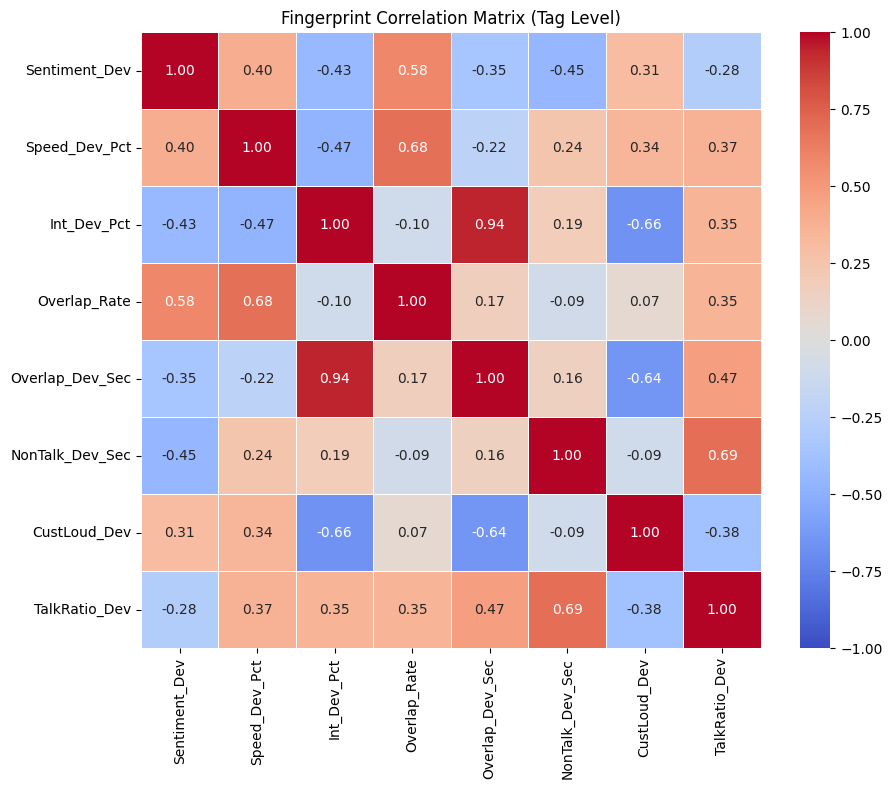


--- 指標間的關聯發現 ---
          Feature_1        Feature_2      Corr
11    Speed_Dev_Pct     Overlap_Rate  0.681462
20      Int_Dev_Pct  Overlap_Dev_Sec  0.937517
22      Int_Dev_Pct     CustLoud_Dev -0.658682
38  Overlap_Dev_Sec     CustLoud_Dev -0.641870
47  NonTalk_Dev_Sec    TalkRatio_Dev  0.691176


In [ ]:
# 計算特徵之間的correlation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 自動提取特徵欄位
# 這次我們直接從 fingerprint_report 提取，避開 Topic 和 Freq
features_to_analyze = [col for col in fingerprint_report.columns if col not in ['Topic', 'Freq']]

print(f"正在分析的指紋特徵: {features_to_analyze}")

# 2. 建立相關係數矩陣
# 改用 fingerprint_report 本身來計算，因為 Dev 欄位只存在於這裡
correlation_matrix = fingerprint_report[features_to_analyze].corr()

# 3. 視覺化 - 繪製熱圖 (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Fingerprint Correlation Matrix (Tag Level)')
plt.show()

# 4. 打印高相關性清單
print("\n--- 指標間的關聯發現 ---")
# 找出相關係數大於 0.6 或小於 -0.6 的組合
high_corr = correlation_matrix.stack().reset_index()
high_corr.columns = ['Feature_1', 'Feature_2', 'Corr']
high_corr = high_corr[(high_corr['Corr'].abs() > 0.6) & (high_corr['Feature_1'] != high_corr['Feature_2'])]
print(high_corr.drop_duplicates(subset=['Corr']))

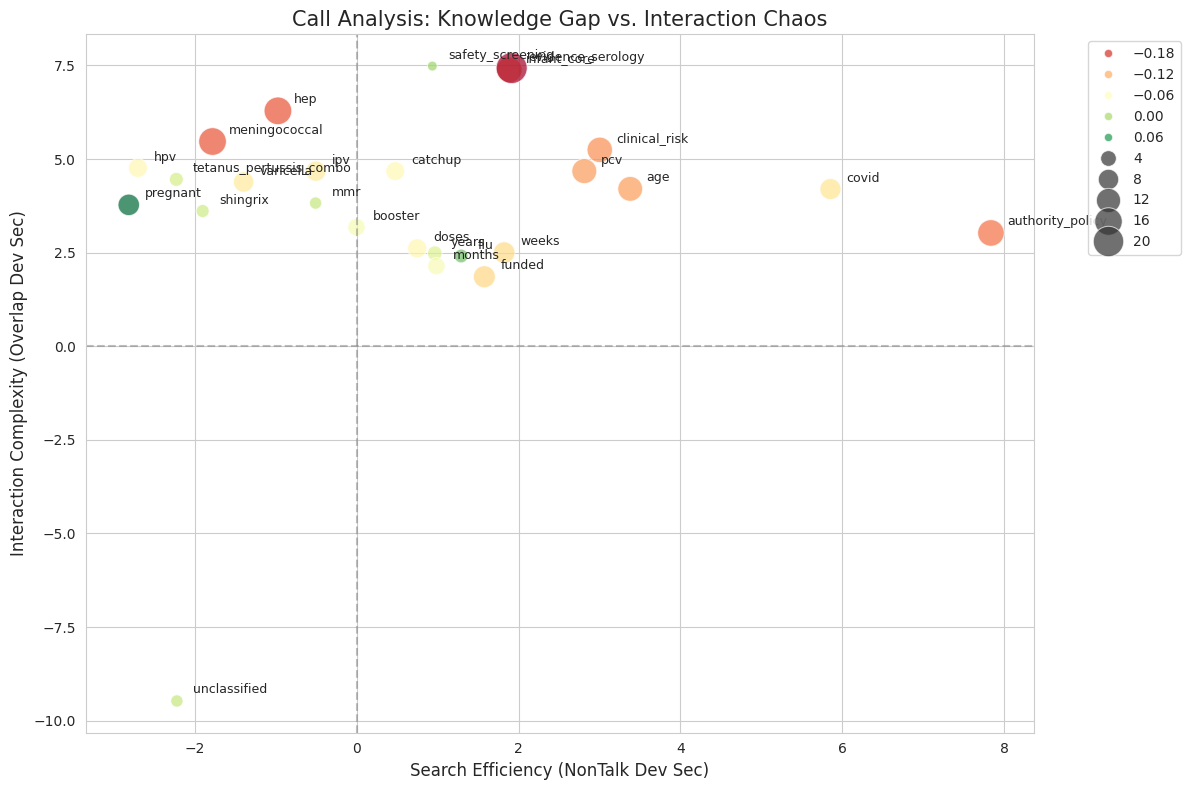

In [ ]:
# 對篩選過的特徵維度畫出象限圖

import matplotlib.pyplot as plt
import seaborn as sns

# 設定圖表風格
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 1. 繪製氣泡圖
# x: 沈默偏離, y: 重疊偏離, size: 絕對值化後的情緒 (讓負值也能顯示大小), hue: 原始情緒
# 註：這裡假設你的數據來源是 fingerprint_report 或 test_candidates
scatter = sns.scatterplot(
    data=fingerprint_report,
    x='NonTalk_Dev_Sec',
    y='Overlap_Dev_Sec',
    size=fingerprint_report['Sentiment_Dev'].abs()*100, # 放大大小差異
    hue='Sentiment_Dev',
    palette='RdYlGn', # 紅(負面) -> 黃 -> 綠(正面)
    sizes=(50, 500),
    alpha=0.7
)

# 2. 畫出象限中線 (平均值線)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 3. 加上標籤 (標註 Topic)
for i in range(fingerprint_report.shape[0]):
    plt.text(
        fingerprint_report.NonTalk_Dev_Sec[i]+0.2,
        fingerprint_report.Overlap_Dev_Sec[i]+0.2,
        fingerprint_report.Topic[i],
        fontsize=9
    )

plt.title('Call Analysis: Knowledge Gap vs. Interaction Chaos', fontsize=15)
plt.xlabel('Search Efficiency (NonTalk Dev Sec)', fontsize=12)
plt.ylabel('Interaction Complexity (Overlap Dev Sec)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

In [ ]:
# 結合原始數據df 與指紋特徵fingerprint_report, 並建立test set

import os
import pandas as pd
from datetime import datetime  # <--- 加入這行

# --- 設定區 ---
TOTAL_TARGET = 100  # 現在你可以隨意修改這個數字 (25, 50, 100...)
NONTALK_DEV_SEC_THRESHOLD = 2
OVERLAP_DEV_SEC_THRESHOLD = 4
SENTIMENT_DEV_THRESHOLD = -0.1
OUTPUT_DIR = '/content/drive/MyDrive/hackathon_team02/output20260400'
UNCLASSIFIED_MIN = round(TOTAL_TARGET / 20) # 暫定TOTAL_TARGET的5%

# 生成時間戳記字串 (格式為: 年月日_時分秒, 例如 20260521_112005)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_FILE = f"test_benchmark_{TOTAL_TARGET}_{timestamp}.csv"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, OUTPUT_FILE)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. 準備數據與基準線 ---
df_exploded = df.explode('tags_list')

# 計算每個話題的平均值
topic_baseline = df_exploded.groupby('tags_list').agg({
    'non_talk_time': 'mean',
    'overlap_sec': 'mean'
}).reset_index().rename(columns={
    'tags_list': 'Topic',
    'non_talk_time': 'avg_nontalk_ms',
    'overlap_sec': 'avg_overlap_sec'
})

# --- 3. 合併與計算「個人」偏離值 ---
# 合併原始資料與話題平均值
df_enriched = df_exploded.merge(
    topic_baseline,
    left_on='tags_list',
    right_on='Topic',
    how='left'
)

# 【核心計算】直接定義為 NonTalk_Dev_Sec (覆蓋掉舊有的話題平均指標)
# NonTalk: (ms - avg_ms) / 1000
df_enriched['NonTalk_Dev_Sec'] = (df_enriched['non_talk_time'] - df_enriched['avg_nontalk_ms']) / 1000
# Overlap: (sec - avg_sec)
df_enriched['Overlap_Dev_Sec'] = (df_enriched['overlap_sec'] - df_enriched['avg_overlap_sec'])

# 併入情緒指標 (從 fingerprint_report 拿，避開重複的 Dev 欄位)
df_enriched = df_enriched.merge(
    fingerprint_report[['Topic', 'Sentiment_Dev']],
    on='Topic',
    how='left'
)

# 2. 定義象限
# 沒有考慮 sentiment
'''
def assign_quadrant(row):
    if row['NonTalk_Dev_Sec'] > 2 and row['Overlap_Dev_Sec'] > 4:
        return "Q1_Extreme"
    elif row['NonTalk_Dev_Sec'] > 2:
        return "Q2_Knowledge"
    elif row['Overlap_Dev_Sec'] > 4:
        return "Q3_Interaction"
    return "Q4_Baseline"

df_enriched['Quadrant'] = df_enriched.apply(assign_quadrant, axis=1)
'''

# 考慮 sentiment
def assign_quadrant_3d(row):
    # 基礎定義
    is_slow = row['NonTalk_Dev_Sec'] > NONTALK_DEV_SEC_THRESHOLD      # 沈默較久
    is_chaotic = row['Overlap_Dev_Sec'] > OVERLAP_DEV_SEC_THRESHOLD   # 重疊較多
    is_stressed = row['Sentiment_Dev'] < SENTIMENT_DEV_THRESHOLD # 情緒較負面 (壓力大)

    if is_slow and is_chaotic:
        base = "Q1_Extreme"
    elif is_slow:
        base = "Q2_Knowledge"
    elif is_chaotic:
        base = "Q3_Interaction"
    else:
        base = "Q4_Baseline"

    # 加上情緒後綴
    if is_stressed:
        return f"{base}_HighPressure" # 高壓力案例
    else:
        return base

# 考慮 "unclassified" tag
def finalize_case_type(row):
    """結合 Topic 標籤與象限邏輯"""
    # 1. 先呼叫基礎象限邏輯
    quadrant = assign_quadrant_3d(row)

    # 2. 判斷是否為 unclassified，若是則加上前綴
    # 這裡假設你的 topic 欄位名稱是 'topic'
    if row.get('Topic') == 'unclassified':
        return f"Unclassified_{quadrant}"

    return quadrant

#df_enriched['Quadrant'] = df_enriched.apply(assign_quadrant_3d, axis=1)
df_enriched['Quadrant'] = df_enriched.apply(finalize_case_type, axis=1)
print(df_enriched.columns)

# ==========================================
# 【新增：排序與去重邏輯】插入在此處
# ==========================================

# 1. 先進行排序：
#    我們希望如果同一通電話有多個標籤，優先保留「高壓 (HighPressure)」
#    以及「偏差值較大 (NonTalk_Dev_Sec)」的紀錄
df_enriched['is_hp'] = df_enriched['Quadrant'].str.contains("HighPressure")

df_enriched = df_enriched.sort_values(
    by=['file_id', 'is_hp', 'NonTalk_Dev_Sec'],
    ascending=[True, False, False]
)

# 2. 執行去重：確保每個 file_id 只會出現一次，成為抽樣池
df_pool = df_enriched.drop_duplicates(subset=['file_id'], keep='first')

print(f"去重完成！原始展開筆數: {len(df_enriched)}, 獨立通話數: {len(df_pool)}")

# --- 5. 抽樣邏輯 (方案 A：優先抽取高壓案例) ---

# 1. 先抽 Unclassified (預留組)
un_pool = df_pool[df_pool['Topic'].astype(str).str.lower() == 'unclassified']
df_un = un_pool.sample(n=min(len(un_pool), UNCLASSIFIED_MIN), random_state=42)

# 設定每個象限中，高壓案例 (HighPressure) 的理想佔比
# Q1, Q3 是互動與極端衝突，給予高比例；Q2, Q4 則是知識與基礎，給予低比例
hp_ratio_settings = {
    "Q1": 0.7,  # Q1 內 80% 優先抽高壓
    "Q2": 0.3,  # Q2 內 30% 優先抽高壓
    "Q3": 0.7,  # Q3 內 70% 優先抽高壓
    "Q4": 0.3   # Q4 內 10% 優先抽高壓
}

sampled_dfs = [df_un] # 把預留的先放進去
already_sampled_ids = set()
ratios = {"Q1": 0.3, "Q2": 0.3, "Q3": 0.3, "Q4": 0.1}
QUAD_TARGET = TOTAL_TARGET - UNCLASSIFIED_MIN

for quad_prefix, total_ratio in ratios.items():
    target_count = round(QUAD_TARGET * total_ratio)
    '''
    # 【關鍵修改】：改用 df_pool，並過濾掉已經被抽走的 IDs
    # 這樣 Q1 抽過的人，就不會在 Q2 重複出現
    subset = df_pool[
        (df_pool['Quadrant'].str.contains(quad_prefix, na=False)) &
        (~df_pool['file_id'].isin(already_sampled_ids))
    ]
    '''
    # 【關鍵修正】：除了比對象限，還要確保 Topic 不是 unclassified
    # 這樣 unclassified 就只會在「預留組」被抽到，不會在「象限組」被重複抽取
    subset = df_pool[
        (df_pool['Quadrant'].str.contains(quad_prefix, na=False)) &
        (~df_pool['file_id'].isin(already_sampled_ids)) &
        (df_pool['Topic'].astype(str).str.lower() != 'unclassified') # <--- 加入這行
    ]

    if subset.empty: continue

    # 方案 A：優先抽高壓
    hp_subset = subset[subset['Quadrant'].str.contains("HighPressure", na=False)]
    normal_subset = subset[~subset['Quadrant'].str.contains("HighPressure", na=False)]

    # 根據之前的配置設定比例
    hp_ratio = hp_ratio_settings.get(quad_prefix, 0.2)
    hp_target_n = round(target_count * hp_ratio)

    take_hp = min(len(hp_subset), hp_target_n)
    sampled_hp = hp_subset.sample(n=take_hp, random_state=42) if take_hp > 0 else pd.DataFrame()

    remaining_gap = target_count - len(sampled_hp)
    take_normal = min(len(normal_subset), remaining_gap)
    sampled_normal = normal_subset.sample(n=take_normal, random_state=42) if take_normal > 0 else pd.DataFrame()

    quad_sampled = pd.concat([sampled_hp, sampled_normal])
    sampled_dfs.append(quad_sampled)
    already_sampled_ids.update(quad_sampled['file_id'].tolist()) # 注意您的欄位是 Case_ID

df_final = pd.concat(sampled_dfs)

# --- 修正後的最後補足邏輯 ---
if len(df_final) < TOTAL_TARGET:
    gap = TOTAL_TARGET - len(df_final)

    # 【關鍵修正】：剩下的池子要排除「已抽過」且「所有 unclassified」
    remaining = df_pool[
        (~df_pool['file_id'].isin(already_sampled_ids)) &
        (df_pool['Topic'].astype(str).str.lower() != 'unclassified') # 排除掉剩下的 unclassified
    ]

    if not remaining.empty:
        extra = remaining.sample(n=min(len(remaining), gap), random_state=42)
        df_final = pd.concat([df_final, extra])

print("目前抽樣中的 Topic 分布：")
print(df_final['Topic'].value_counts())
# 1. 先依照 'file_id' 欄位進行升序排序 (A-Z)
df_final = df_final.sort_values(by='file_id', ascending=True)
# --- 6. 最終格式化輸出 ---
final_output = []
for _, row in df_final.head(TOTAL_TARGET).iterrows():
    final_output.append({
        'Case_ID': row['file_id'],
        'Parent_Folder': row['file_folder'],
        'Topic': row['Topic'],
        'Challenge_Category': row['Quadrant'],
        'NonTalk_Dev_Sec': round(row['NonTalk_Dev_Sec'], 2),
        'Overlap_Dev_Sec': round(row['Overlap_Dev_Sec'], 2),
        'Sentiment_Dev': round(row['Sentiment_Dev'], 3),
        'Silence_Total_Sec': round(row['non_talk_time'] / 1000, 2),
        'Overlap_Total_Sec': round(row['overlap_sec'], 2),
        'AI_Success_Target': f"Resolve {round(row['NonTalk_Dev_Sec'], 1)}s dev in {row['Topic']}"
    })

pd.DataFrame(final_output).to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f"✅ 完成！檔案已儲存至 {OUTPUT_PATH}")

Index(['file_folder', 'file_id', 'text', 'sentiment', 'talk_speed',
       'overlap_rate', 'overlap_sec', 'interruption_count', 'non_talk_time',
       'agent_loudness', 'customer_loudness', 'talk_ratio', 'issue_count',
       'has_issue', 'issues_summary', 'tags_list', 'Topic', 'avg_nontalk_ms',
       'avg_overlap_sec', 'NonTalk_Dev_Sec', 'Overlap_Dev_Sec',
       'Sentiment_Dev', 'Quadrant'],
      dtype='object')
去重完成！原始展開筆數: 10060, 獨立通話數: 1781
目前抽樣中的 Topic 分布：
Topic
clinical_risk              16
meningococcal              10
hep                         7
years                       7
evidence_serology           5
unclassified                5
booster                     5
authority_policy            4
infant_core                 4
doses                       4
tetanus_pertussis_combo     4
shingrix                    4
age                         3
flu                         3
pcv                         3
pregnant                    3
months                      2
mmr           

In [ ]:
# 檢查這兩個 Topic 的平均值是否真的這麼接近
print(df_final[df_final['Topic'].str.lower() == 'unclassified']['file_id'])
print(topic_baseline[topic_baseline['Topic'].isin(['doses', 'weeks'])])

print(len(df))


7599    d2c6dbba-85c3-4012-8327-3554b986783e_analysis_...
89      c4e41589-5052-4228-b2ca-6f16993049ca_analysis_...
Name: file_id, dtype: object
    Topic  avg_nontalk_ms  avg_overlap_sec
6   doses    13856.077878        20.364175
24  weeks    14930.338398        20.250496
1781


In [ ]:
# 手動加入某個檔案到test set的excel file

import pandas as pd
import os

# --- 設定區 ---
OUTPUT_DIR = '/content/drive/MyDrive/hackathon_team02/output20260400'
OUTPUT_FILE = "test_benchmark_25_20260522_041352.csv"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, OUTPUT_FILE)
FILE_TO_ADD = "b22708c6-a567-4a31-bcbc-16787adee208_analysis_redacted_2026-04-14T01_27_41Z.json"
#"d6c68dff-959c-4866-84d2-5e5f9f552826_analysis_redacted_2026-04-17T01_49_53Z.json"
FILE_PATH = os.path.join(OUTPUT_DIR, FILE_TO_ADD)

def append_to_benchmark_csv(case_id, source_df, csv_path='test_benchmark_25_20260520_232127.csv'):
    """
    根據提供的格式邏輯，將特定 case_id 的統計數據追加到 CSV
    """
    # 1. 篩選該筆資料
    row = source_df[source_df['file_id'] == case_id]

    if row.empty:
        print(f"⚠️ 找不到 Case_ID: {case_id}")
        return

    # 取得第一筆符合的資料 (Series)
    row = row.iloc[0]

    # 2. 嚴格依照 final_output 的格式建立字典
    formatted_entry = {
        'Case_ID': row['file_id'],
        'Parent_Folder': row['file_folder'],
        'Topic': row['Topic'],
        'Challenge_Category': row['Quadrant'],
        'NonTalk_Dev_Sec': round(row['NonTalk_Dev_Sec'], 2),
        'Overlap_Dev_Sec': round(row['Overlap_Dev_Sec'], 2),
        'Sentiment_Dev': round(row['Sentiment_Dev'], 3),
        'Silence_Total_Sec': round(row['non_talk_time'] / 1000, 2),  # 毫秒轉秒
        'Overlap_Total_Sec': round(row['overlap_sec'], 2),
        'AI_Success_Target': f"Resolve {round(row['NonTalk_Dev_Sec'], 1)}s dev in {row['Topic']}"
    }

    # 轉換成 DataFrame
    new_df = pd.DataFrame([formatted_entry])

    # 3. 寫入 CSV
    if not os.path.exists(csv_path):
        # 建立新檔 (含標題)
        new_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"✅ 建立新檔並寫入: {case_id}")
    else:
        # 追加模式 (不含標題)
        new_df.to_csv(csv_path, mode='a', index=False, header=False, encoding='utf-8-sig')
        print(f"✅ 成功追加格式化數據: {case_id}")
# --- 範例整合流程 ---
# 假設你的計算結果存放在 df_enriched 中
# case_id = "d6c68dff-959c-4866-84d2-5e5f9f552826_analysis_redacted.json"
append_to_benchmark_csv(FILE_TO_ADD, df_enriched, OUTPUT_PATH)

✅ 成功追加格式化數據: b22708c6-a567-4a31-bcbc-16787adee208_analysis_redacted_2026-04-14T01_27_41Z.json


In [ ]:
# 假設你的 DataFrame 叫 df_final
target_id = "d2c6dbba-85c3-4012-8327-3554b986783e_analysis_redacted_2026-04-17T01_10_22Z.json"

# 使用 loc 篩選
view_row = df.loc[df['file_id'] == target_id]

# 顯示結果
#print(view_row)
print(df.loc[df['file_id'] == target_id].T)

                                                                 1356
file_folder                                            output20260417
file_id             d2c6dbba-85c3-4012-8327-3554b986783e_analysis_...
text                [name] and [name] speaking. oh, i oh, hi there...
sentiment                                                         0.5
talk_speed                                                      136.5
overlap_rate                                                      0.0
overlap_sec                                                       0.0
interruption_count                                                  0
non_talk_time                                                    7439
agent_loudness                                              80.611083
customer_loudness                                           81.584961
talk_ratio                                                   0.429924
issue_count                                                         0
has_issue           

In [ ]:
# 把 CSV 內的JSON檔案, 複製一份到新資料夾, 然後產生壓縮檔以便下載

import pandas as pd
import os
import shutil
import zipfile
from google.colab import files

OUTPUT_DIR = '/content/drive/MyDrive/hackathon_team02/output20260400'
OUTPUT_FILE = "test_benchmark_25_20260522_041352.csv"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, OUTPUT_FILE)

def organize_and_zip(csv_file_path):
    # 2. 獲取 CSV 檔名並在 /content 創建暫存資料夾
    base_name = os.path.splitext(os.path.basename(csv_file_path))[0]
    local_target_dir = f"/content/{base_name}"

    if not os.path.exists(local_target_dir):
        os.makedirs(local_target_dir)
        print(f"創建暫存資料夾: {local_target_dir}")

    # 讀取 CSV
    try:
        df = pd.read_csv(csv_file_path)
    except Exception as e:
        print(f"讀取 CSV 失敗: {e}")
        return

    # 3. 遍歷 CSV 並從 Drive 複製檔案
    copied_count = 0
    for index, row in df.iterrows():
        case_id = str(row['Case_ID']).strip()
        source_parent = str(row['Parent_Folder']).strip()
        source_parent = os.path.join(OUTPUT_DIR, source_parent)
        if not os.path.exists(source_parent):
            print(f"警告: 找不到雲端路徑 {source_parent}")
            continue

        found = False
        file_name = case_id if case_id.endswith('.json') else f"{case_id}.json"
        source_path = os.path.join(source_parent, file_name)

        if os.path.exists(source_path):
            target_path = os.path.join(local_target_dir, file_name)
            shutil.copy2(source_path, target_path)
            copied_count += 1
            found = True
        else:
            # 模糊搜尋包含 ID 的檔案
            for f in os.listdir(source_parent):
                if case_id in f and f.endswith('.json'):
                    shutil.copy2(os.path.join(source_parent, f), os.path.join(local_target_dir, f))
                    copied_count += 1
                    found = True
                    break

        if not found:
            print(f"錯誤: 找不到案件 {case_id}")

    # 4. 產生壓縮檔
    zip_filename = f"/content/{base_name}.zip"
    if copied_count > 0:
        with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, dirs, files_in_dir in os.walk(local_target_dir):
                for file in files_in_dir:
                    zipf.write(os.path.join(root, file), arcname=file)
        print(f"壓縮完成，共 {copied_count} 個檔案: {zip_filename}")

        # 5. 自動下載到本地
        print("正在啟動自動下載...")
        files.download(zip_filename)

        # 6. 【清理機制】刪除暫存資料夾
        # 注意：我們通常保留 .zip 檔直到下載完成，但刪除展開的資料夾以節省空間
        try:
            shutil.rmtree(local_target_dir)
            print(f"已清理暫存資料夾: {local_target_dir}")
        except Exception as e:
            print(f"清理資料夾時發生錯誤: {e}")

    else:
        print("沒有複製任何檔案，流程結束。")
        if os.path.exists(local_target_dir):
            shutil.rmtree(local_target_dir)

if __name__ == '__main__':
    # 使用時請將 'example_config.csv' 改為您的檔名
    organize_and_zip(OUTPUT_PATH)

創建暫存資料夾: /content/test_benchmark_25_20260522_041352
壓縮完成，共 27 個檔案: /content/test_benchmark_25_20260522_041352.zip
正在啟動自動下載...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

已清理暫存資料夾: /content/test_benchmark_25_20260522_041352


In [ ]:
# 把 CSV 內的JSON檔案, 複製一份到新資料夾, 然後擷取對話內容貼到新的CSV檔案, 然後下載

import pandas as pd
import os
import shutil
import zipfile
from google.colab import files as colab_files # 修改這裡，避免名稱衝突
import json
import os
import csv
import hashlib

BASE_DIR = '/content/drive/MyDrive/hackathon_team02/output20260400'
INPUT_FILE = "test_benchmark_25_20260522_041352.csv"
INPUT_PATH = os.path.join(BASE_DIR, INPUT_FILE)
OUTPUT_FILE = INPUT_FILE[:-4] + "_transcripts.csv"#"test_benchmark_25_20260522_041352_transcripts.csv"
OUTPUT_PATH = os.path.join(BASE_DIR, OUTPUT_FILE)
OUTPUT_FILE_2 = INPUT_FILE[:-4] + ".json"

print(OUTPUT_FILE, OUTPUT_FILE_2)

def process_csv_to_json(input_file, output_file):

    # 讀取 CSV
    df = pd.read_csv(input_file)

    # 清理欄位（避免大小寫問題）
    df.columns = [c.strip() for c in df.columns]

    # 確保 sequence 是數字
    df["Sequence"] = pd.to_numeric(df["Sequence"], errors="coerce")

    # drop 壞資料
    df = df.dropna(subset=["File_ID", "Sequence"])

    # grouping
    conversations = []

    for file_id, group in df.groupby("File_ID"):
        # 1. 計算 line_count (總 Sequence 數)
        line_count = len(group)

        # 2. 計算前三句話的 MD5 (選用)
        # 取出前三句的 Text 內容並合併
        first_three_texts = "".join(group.sort_values('Sequence')['Text'].head(3).astype(str))
        full_hash = hashlib.md5(first_three_texts.encode('utf-8')).hexdigest()
        md5_hash = full_hash[:8]

        group = group.sort_values("Sequence")

        turns = [
            {
                "sequence": int(row["Sequence"]),
                "role": str(row["Role"]),
                "text": str(row["Text"])
            }
            for _, row in group.iterrows()
        ]

        conversations.append({
            "file_id": file_id,
            "metadata_verification": {
                "total_turns": line_count,
                "first_three_turns_hash": md5_hash
            },
            "turns": turns
        })

    # 輸出 JSON
    output = {"conversations": conversations}

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print("✅ JSON 轉換完成")
    print("正在啟動自動下載...")
    colab_files.download(output_file)



def process_transcripts_to_single_csv(input_folder, output_file):
    all_rows = []

    # 獲取所有 json 檔案並排序，確保處理順序一致
    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.json')])

    if not files:
        print("資料夾內沒有找到 JSON 檔案！")
        return

    for filename in files:
        file_path = os.path.join(input_folder, filename)

        # 提取 File_ID (取檔名的前 6 碼或整段 ID)
        file_id = filename.split('_')[0]

        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            # 檢查是否有 Transcript 欄位
            if "Transcript" in data:
                print(f"正在處理檔案: {filename}...")

                # 遍歷對話內容，並加入 Sequence (從 1 開始)
                for index, entry in enumerate(data["Transcript"], start=1):
                    role = entry.get("ParticipantId", "UNKNOWN")
                    content = entry.get("Content", "").replace('\n', ' ') # 移除換行符號避免破壞 CSV 格式

                    all_rows.append([file_id, index, role, content])
            else:
                print(f"跳過檔案 (無 Transcript): {filename}")

        except Exception as e:
            print(f"讀取檔案 {filename} 時發生錯誤: {e}")

    # 寫入 CSV
    with open(output_file, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.writer(f)
        # 寫入標題列
        writer.writerow(["File_ID", "Sequence", "Role", "Text"])
        # 寫入所有資料
        writer.writerows(all_rows)

    print(f"\n--- 完成！所有通話紀錄已整合至: {output_file} ---")
    # 5. 自動下載到本地
    print("正在啟動自動下載...")
    colab_files.download(output_file)

    # 6. 【清理機制】刪除暫存資料夾
    # 注意：我們通常保留 .zip 檔直到下載完成，但刪除展開的資料夾以節省空間
    '''
    try:
        shutil.rmtree(input_folder)
        print(f"已清理暫存資料夾: {input_folder}")
    except Exception as e:
        print(f"清理資料夾時發生錯誤: {e}")
    '''
# 執行：將當前資料夾所有 JSON 轉成一個 CSV
# export_all_to_csv('./raw_data', 'all_transcripts.csv')

def organize_and_zip(csv_file_path):
    # 2. 獲取 CSV 檔名並在 /content 創建暫存資料夾
    base_name = os.path.splitext(os.path.basename(csv_file_path))[0]
    local_target_dir = f"/content/{base_name}"

    if not os.path.exists(local_target_dir):
        os.makedirs(local_target_dir)
        print(f"創建暫存資料夾: {local_target_dir}")

    # 讀取 CSV
    try:
        df = pd.read_csv(csv_file_path)
    except Exception as e:
        print(f"讀取 CSV 失敗: {e}")
        return

    # 3. 遍歷 CSV 並從 Drive 複製檔案
    copied_count = 0
    for index, row in df.iterrows():
        case_id = str(row['Case_ID']).strip()
        source_parent = str(row['Parent_Folder']).strip()
        source_parent = os.path.join(BASE_DIR, source_parent)
        if not os.path.exists(source_parent):
            print(f"警告: 找不到雲端路徑 {source_parent}")
            continue

        found = False
        file_name = case_id if case_id.endswith('.json') else f"{case_id}.json"
        source_path = os.path.join(source_parent, file_name)

        if os.path.exists(source_path):
            target_path = os.path.join(local_target_dir, file_name)
            shutil.copy2(source_path, target_path)
            copied_count += 1
            found = True
        else:
            # 模糊搜尋包含 ID 的檔案
            for f in os.listdir(source_parent):
                if case_id in f and f.endswith('.json'):
                    shutil.copy2(os.path.join(source_parent, f), os.path.join(local_target_dir, f))
                    copied_count += 1
                    found = True
                    break

        if not found:
            print(f"錯誤: 找不到案件 {case_id}")

    if not copied_count > 0:
        print("沒有複製任何檔案，流程結束。")
        if os.path.exists(local_target_dir):
            shutil.rmtree(local_target_dir)

    return local_target_dir

if __name__ == '__main__':
    # 使用時請將 'example_config.csv' 改為您的檔名
    local_target_dir = organize_and_zip(INPUT_PATH)
    print(local_target_dir)
    process_transcripts_to_single_csv(local_target_dir, OUTPUT_FILE)
    process_csv_to_json(OUTPUT_FILE, OUTPUT_FILE_2)

test_benchmark_25_20260522_041352_transcripts.csv test_benchmark_25_20260522_041352.json
/content/test_benchmark_25_20260522_041352
正在處理檔案: 0323a83a-76b5-4afa-9b7c-1a76e0d964f9_analysis_redacted_2026-04-01T23_06_40Z.json...
正在處理檔案: 0d5193fd-a68c-4d3c-8f00-8c4671c3a6a6_analysis_redacted_2026-04-14T03_52_12Z.json...
正在處理檔案: 149b622b-c982-456b-ba80-d5837af14027_analysis_redacted_2026-04-14T01_58_02Z.json...
正在處理檔案: 1b854767-f544-40ba-a3d9-2dc5646fc67e_analysis_redacted_2026-04-14T23_39_48Z.json...
正在處理檔案: 2c948cca-2b7f-464c-89a8-52618b50d82a_analysis_redacted_2026-04-15T03_07_44Z.json...
正在處理檔案: 4ba5a3af-74db-4a1b-a661-241c0c6cfec4_analysis_redacted_2026-04-13T00_31_18Z.json...
正在處理檔案: 4d6e33c6-f3db-4f00-904c-1534658f0086_analysis_redacted_2026-04-09T22_06_32Z.json...
正在處理檔案: 5f0b0897-c798-4367-9a74-4a52ff0b1ee4_analysis_redacted_2026-04-14T21_46_39Z.json...
正在處理檔案: 674ff6e3-1513-4b38-931c-40844d484f1c_analysis_redacted_2026-04-13T02_06_59Z.json...
正在處理檔案: 6ade4697-5ba8-4d9b-a63c-c38b09af

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ JSON 轉換完成
正在啟動自動下載...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>